In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision import models
from torchvision.datasets import DatasetFolder 
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import math
from datetime import datetime
import random
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
# from pytorch_metric_learning import losses


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

now = datetime.now()
date = now.strftime("%Y %m %d")

Using device: cuda


In [62]:
class C:
    batch_size = 32
    raw_path = "/kaggle/input/datasets/atiaisaac/gsoc-2025-test-ii/lens-finding-test"
    train_data = os.path.join(raw_path,"train")
    test_data = os.path.join(raw_path,"test")
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    weights = f"weights_fl_{date}.pth"
    learning_rate = 1e-3
    class_to_idx={'nonlens': 0, 'lens': 1}

In [39]:
def npy_loader(path):
    sample = np.load(path)
    tensor = torch.from_numpy(sample).float()
    return tensor

def target_transform(label):
    return 1 - label

In [40]:
print("number of images in train 'lenses': {}".format(len(glob.glob(os.path.join(C.train_data,"train_lenses/*")))))
print("number of images in train 'non-lense': {}".format(len(glob.glob(os.path.join(C.train_data,"train_nonlenses/*")))))

number of images in train 'lenses': 1730
number of images in train 'non-lense': 28675


In [41]:
print("number of images in test 'lense': {}".format(len(glob.glob(os.path.join(C.test_data,"test_lenses/*")))))
print("number of images in test 'nonlense': {}".format(len(glob.glob(os.path.join(C.test_data,"test_nonlenses/*")))))

number of images in test 'lense': 195
number of images in test 'nonlense': 19455


In [42]:
class MyScale(object):
    def __call__(self, x):
        min_pixel = torch.min(x)
        max_pixel = torch.max(x)
        x_norm = (x - min_pixel) / (max_pixel - min_pixel)
        return np.clip(x_norm, 0, 1)

#### Creating a train and validation set by stratifying lables. This will help in keeping the ratio of minority to majority classes the same acorss splits

In [43]:
all_files = []
all_labels = []

for class_idx, class_name in enumerate(sorted(os.listdir(C.train_data))):
    class_path = os.path.join(C.train_data, class_name)
    if os.path.isdir(class_path):
        for file in glob.glob(os.path.join(class_path, '*.npy')):
            all_files.append(file)
            all_labels.append(class_idx)

all_labels = 1 - np.array(all_labels)

# Stratified split
train_idx, val_idx = train_test_split(
    np.arange(len(all_labels)),
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

In [44]:
train_count = np.bincount(all_labels[train_idx])
val_count = np.bincount(all_labels[val_idx])
print(f"Training set class distribution: {train_count}")
print(f"Validation set class distribution: {val_count}")

Training set class distribution: [22940  1384]
Validation set class distribution: [5735  346]


In [45]:
train_df = DatasetFolder(
    root=C.train_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        v2.RandomHorizontalFlip(p = 0.5),
        v2.RandomVerticalFlip(p = 0.5),
        v2.RandomApply(
            transforms = [
                v2.RandomAffine(
                    degrees = (0, 10),
                    scale = (1.0, 1.2),
                    # translate = (0.2, 0.2)
                )
            ],
            p = 0.3
        ),
        # v2.RandomGrayscale(p = 0.2),
        MyScale(),
        # v2.Normalize(
        #     mean=C.mean,
        #     std=C.std
        # )
    ]),
    target_transform=target_transform
)

val_df = DatasetFolder(
    root=C.train_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        MyScale(),
        # v2.Normalize(
        #     mean=C.mean,
        #     std=C.std
        # )
    ]),
    target_transform=target_transform
)

test_df = DatasetFolder(
    root=C.test_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        MyScale(),
        # v2.Normalize(
        #     mean=C.mean,
        #     std=C.std
        # )
    ]),
    target_transform=target_transform
)

In [46]:
train_subset = Subset(train_df, train_idx)
val_subset = Subset(val_df, val_idx)

## Added weighted sampler for samples that are less represented

In [47]:
labels = all_labels[train_idx]
class_counts = train_count # [n_nonlens, n_lens]
weights = 1.0 / class_counts[labels]       # inverse-frequency per sample
sampler = WeightedRandomSampler(
    torch.tensor(weights, dtype=torch.float),
    num_samples=len(train_subset),
    replacement=True
)

In [48]:
train_loader = DataLoader(
    train_subset, 
    batch_size=C.batch_size, 
    sampler=sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_subset,
    batch_size=C.batch_size,
    shuffle=True,
    num_workers=0
)
    
    
test_loader = DataLoader(
    test_df, 
    batch_size=C.batch_size, 
    shuffle=False, 
    num_workers=0
)

In [49]:
def visualize_batch(dataloader, num_batches=1, class_names=None):
    if class_names is None:
        class_names = list(dataloader.dataset.class_to_idx.keys())
    
    # Get a batch of images
    for batch_idx, (images, labels) in enumerate(dataloader):
        if batch_idx >= num_batches:
            break
            
        # Convert tensors to numpy for plotting
        images = images.numpy()
        
        # Create a grid of subplots
        fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 12))
        axes = axes.flatten()
        
        # Plot each image in the batch
        for i in range(min(16, len(images))):

            img = torch.from_numpy(images[i]).float()
            img = (img * torch.tensor(C.std).view(3, 1, 1)) + torch.tensor(C.mean).view(3, 1, 1)
            img = torch.permute(img, (1,2,0))
            label = labels[i].item()
            
            # Determine how to display the image based on its shape
            if len(img.shape) == 3:  # Color image (C, H, W)
                if img.shape[2] == 1:  # Single channel
                    axes[i].imshow(img)
                else:  # Multiple channels (e.g., RGB)
                    # Move channels to the end for matplotlib (H, W, C)
                    # img_display = np.transpose(img, (1, 2, 0))
                    img_display = img
                    # If more than 3 channels, just use first 3
                    if img_display.shape[2] > 3:
                        img_display = img_display[:, :, :3]
                    axes[i].imshow(img_display)
            elif len(img.shape) == 2:  # Grayscale image (H, W)
                axes[i].imshow(img, cmap='gray')
            else:  # Handle other shapes appropriately
                axes[i].text(0.5, 0.5, f"Shape: {img.shape}", 
                             ha='center', va='center', transform=axes[i].transAxes)
            
            # Add class label
            axes[i].set_title(f"Class: {class_names[label]}")
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.suptitle(f"Batch {batch_idx+1}")
        plt.show()

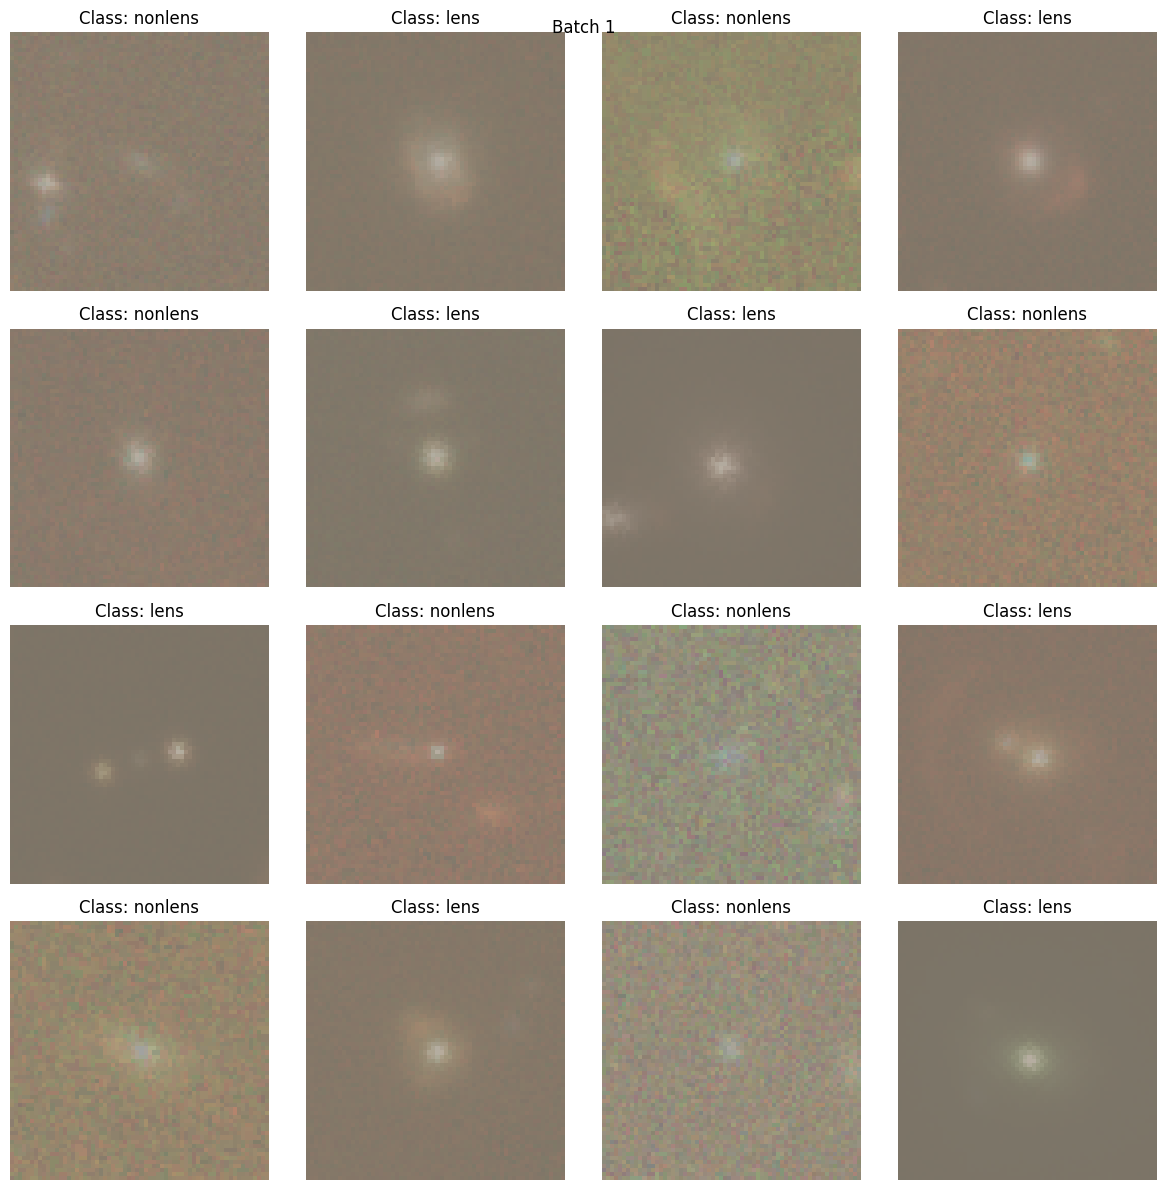

In [50]:
visualize_batch(train_loader, num_batches=1, class_names=list(C.class_to_idx.keys()))

In [51]:
base = models.resnet18()
output_dim = base.fc.in_features
print(f"Output dimension: {output_dim}")

class Encoder(nn.Module):
    def __init__(self, net=base):
        super().__init__()
        self.net = nn.Sequential(*list(net.children())[:-1])

    def forward(self, x):
        x = self.net(x)  # (B, 1280, 1, 1)
        x = x.flatten(1)  # Flatten to (B, 1280)
        return x

Output dimension: 512


In [52]:
class LinearClassifier(nn.Module):
    def __init__(self, feature_dim: int = output_dim, num_classes: int = 1):
        super().__init__()
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.dropout = nn.Dropout(0.2)
        self.head = nn.Linear(feature_dim, self.num_classes)

    def forward(self, features):   
        return self.head(features)

In [53]:
class FullModel(nn.Module):
    """Combined encoder + projection head for Phase 1."""

    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.classifier  = LinearClassifier()

    def forward(self, x):
        features = self.encoder(x)    
        output = self.classifier(features) 
        return output

In [54]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [55]:
def train(model, loader, optimizer, scheduler = None):
    model.train()
    
    losses = AverageMeter()
    # top1 = AverageMeter()

    all_probs, all_labels = [], []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.float().to(DEVICE)
        bsz = labels.shape[0]
        
        output = model(images)
        
        loss = torchvision.ops.sigmoid_focal_loss(output, labels.unsqueeze(1), reduction="mean")
        losses.update(loss.item(), bsz)
        
        probs  = torch.sigmoid(output)          # (B,) in [0,1]
        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    auc_roc = auc(fpr, tpr)
    scheduler.step()
    return losses.avg, auc_roc

def validate(model, loader, scheduler = None):
    model.eval()
    
    losses = AverageMeter()
    # top1 = AverageMeter()

    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.float().to(DEVICE)
            bsz = labels.shape[0]
        
            output = model(images)
            
            loss = torchvision.ops.sigmoid_focal_loss(output, labels.unsqueeze(1), reduction="mean")
            losses.update(loss.item(), bsz)
            
            probs  = torch.sigmoid(output)          # (B,) in [0,1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        auc_roc = auc(fpr, tpr)
        # scheduler.step(auc_roc)

    return losses.avg, auc_roc

def fit(model, epochs=30, print_freq=5):
    # pos_weight = torch.tensor([train_count[0].item() / train_count[1].item()], device=DEVICE)
    # loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=C.learning_rate)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    history = {"loss": [], "auc": [], "val_loss":[], "val_auc":[]}

    model.to(DEVICE)

    for epoch in range(epochs):
        loss, auc = train(model, train_loader, optimizer, scheduler=scheduler)
        val_loss, val_auc = validate(model, val_loader)
        
        history["loss"].append(loss)
        history["auc"].append(auc)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        if (epoch + 1) % print_freq == 0:
            print(
                f"  Epoch {epoch+1:3d}/{epochs}  |"
                f" loss: {loss:.4f}  |  auc: {auc:.4f}  |" 
                f" val_loss: {val_loss:.4f}  |  val_auc: {val_auc:.4f}"
            )
    return history
        

In [56]:
@torch.no_grad()
def predict(model, loader):
    """
    Run model over a DataLoader and return (probs, labels) as numpy arrays.
    Sigmoid is applied here so output is in [0, 1].
    """
    model.eval()
    all_probs, all_labels, y_preds = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        logits = model(images).squeeze(1)       # (B,)
        probs  = torch.sigmoid(logits)          # (B,) in [0,1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
        y_preds.extend((probs > 0.5).long().cpu().numpy())
    return np.array(all_probs), np.array(all_labels), np.array(y_preds)


In [57]:
model = FullModel()
train = fit(
    model,
    print_freq=1
)

  Epoch   1/30  | loss: 0.0330  |  auc: 0.9495  | val_loss: 0.0137  |  val_auc: 0.9416
  Epoch   2/30  | loss: 0.0242  |  auc: 0.9729  | val_loss: 0.0232  |  val_auc: 0.9703
  Epoch   3/30  | loss: 0.0210  |  auc: 0.9797  | val_loss: 0.0119  |  val_auc: 0.9819
  Epoch   4/30  | loss: 0.0192  |  auc: 0.9829  | val_loss: 0.0351  |  val_auc: 0.9794
  Epoch   5/30  | loss: 0.0174  |  auc: 0.9860  | val_loss: 0.0434  |  val_auc: 0.9815
  Epoch   6/30  | loss: 0.0169  |  auc: 0.9869  | val_loss: 0.0083  |  val_auc: 0.9850
  Epoch   7/30  | loss: 0.0141  |  auc: 0.9908  | val_loss: 0.0133  |  val_auc: 0.9864
  Epoch   8/30  | loss: 0.0129  |  auc: 0.9923  | val_loss: 0.0216  |  val_auc: 0.9833
  Epoch   9/30  | loss: 0.0140  |  auc: 0.9910  | val_loss: 0.0169  |  val_auc: 0.9882
  Epoch  10/30  | loss: 0.0118  |  auc: 0.9934  | val_loss: 0.0249  |  val_auc: 0.9879
  Epoch  11/30  | loss: 0.0103  |  auc: 0.9949  | val_loss: 0.0137  |  val_auc: 0.9881
  Epoch  12/30  | loss: 0.0101  |  auc: 0.9

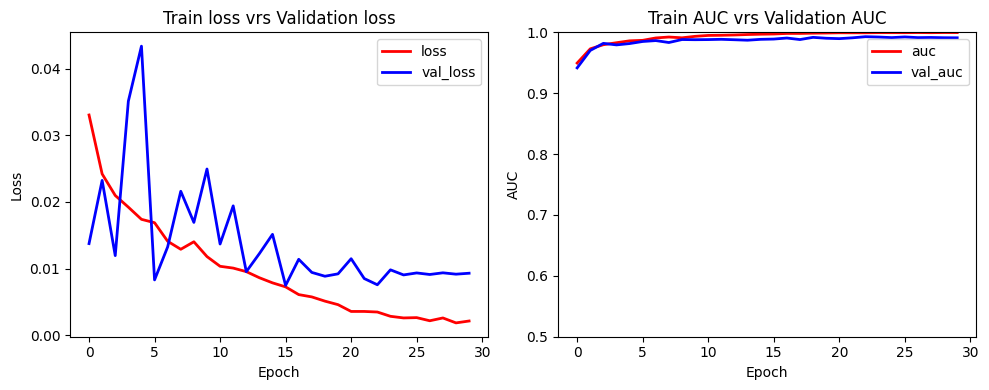

In [58]:
def plot_training_curves(history, save_path="training_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history["loss"], lw=2, color="red", label="loss")
    axes[0].plot(history["val_loss"], lw=2, color="blue", label="val_loss")
    axes[0].set_title("Train loss vrs Validation loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["auc"], lw=2, color="red", label="auc")
    axes[1].plot(history["val_auc"], lw=2, color="blue", label="val_auc")
    axes[1].set_title("Train AUC vrs Validation AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].set_ylim(0.5, 1.0)
    axes[1].legend()

    plt.tight_layout()
    # plt.savefig(save_path, dpi=150)
    plt.show()

plot_training_curves(train)

In [ ]:
def plot_roc(model, loader, save_path="roc_curve.png"):
    probs, labels, y_preds = predict(model, loader)

    fpr, tpr, thresholds = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    # Youden's J statistic → optimal operating threshold
    j_scores   = tpr - fpr
    best_idx   = np.argmax(j_scores)
    # best_thresh = thresholds[best_idx]

    report = classification_report(
            labels, 
            y_preds,
            target_names = list(C.class_to_idx.keys())
        )
    print(report)

    cm = confusion_matrix(
        labels, 
        y_preds,
        labels = list(C.class_to_idx.values())
    )
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=list(C.class_to_idx.keys())
                                 )
    disp.plot()
    
    print(f"(TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f})")
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, lw=2, color="steelblue",
             label=f"Oversample + focal loss  (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title("ROC Curve — Gravitational Lens Classifier")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"  Saved → {save_path}")

              precision    recall  f1-score   support

     nonlens       1.00      0.99      1.00     19455
        lens       0.53      0.81      0.64       195

    accuracy                           0.99     19650
   macro avg       0.76      0.90      0.82     19650
weighted avg       0.99      0.99      0.99     19650

(TPR=0.938, FPR=0.038)


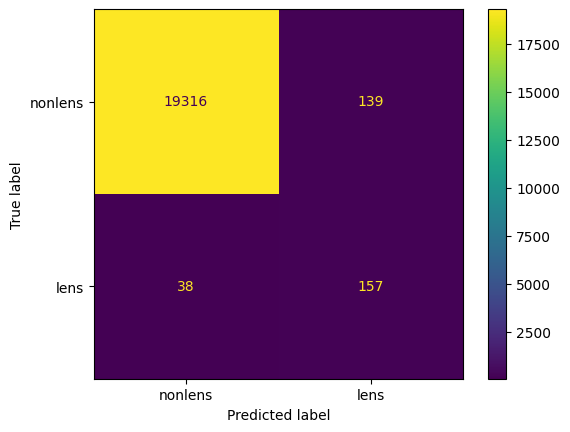

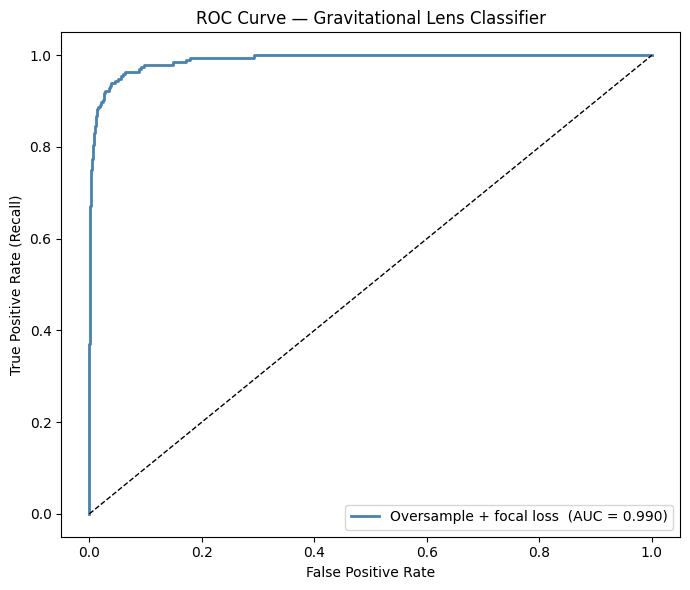

  Saved → roc_curve.png


In [60]:
plot_roc(model, test_loader)

In [63]:
torch.save(model.state_dict(), C.weights)